In [2]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv

In [4]:
load_dotenv()

True

In [5]:
llm = HuggingFaceEndpoint(
    repo_id = "Qwen/Qwen2.5-7B-Instruct",
    task = "conversational"
 )

model = ChatHuggingFace(llm = llm)

c:\Users\sushm\Desktop\Web development\Youtube\AI Engineering\LangGraph\newenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
class LLMState(TypedDict):
    question: str
    answer:str

In [7]:
def ChatQA(state:LLMState) -> LLMState:
    ques = state['question']

    prompt = f'Answer the following {ques}'

    ans = model.invoke(prompt).content

    state['answer'] = ans

    return state

In [8]:
#define your graph
graph = StateGraph(LLMState)

#add nodes to your graph
graph.add_node('ChatQA', ChatQA)

#add edges to your graph
graph.add_edge(START,'ChatQA')
graph.add_edge('ChatQA',END)

#complile the graph
workflow = graph.compile()

In [ ]:
#execute the graph
initial_state = {'question':'How is foreign policy of India?'}
final_state = workflow.invoke(initial_state)
print(final_state['answer'])

{'question': 'How is foreign policy of India?', 'answer': "India's foreign policy is rooted in several core principles and aims to maintain a robust and multifaceted approach to international relations. Here are some key aspects of India's foreign policy:\n\n1. **Non-Alignment**: Post-independence, India adopted a policy of non-alignment, which meant not aligning with any major power blocs. This policy has evolved over time, with India maintaining a strategic autonomy.\n\n2. **Pivot to Asia-Pacific**: In recent years, India has increased its focus on the Asia-Pacific region, recognizing the growing importance of this region in global affairs. This is evident in India's Quadrilateral Security Dialogue (Quad) partnership with the United States, Japan, and Australia.\n\n3. **Strategic Partnerships**: India has developed strategic partnerships with several countries, including the United States, France, Russia, and Israel. These partnerships focus on areas such as defense, technology, and 

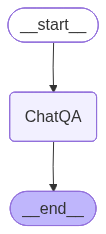

In [10]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())